In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import pipeline as pipeline
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print(pipeline.__file__)

/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/pipeline.py


In [5]:
import os

def list_all_csv_files(dir_path):
    """
    주어진 dir_path 아래의 모든 하위 디렉토리를 포함하여
    .csv 확장자를 가진 파일의 전체 경로를 리스트로 반환합니다.
    """
    csv_files = []
    for root, dirs, files in os.walk(dir_path):
        for file in files:
            if file.lower().endswith('.csv'):
                csv_files.append(os.path.join(root, file))
    return csv_files

dir_path = './data_ready/input_data/NR'
csv_files = list_all_csv_files(dir_path)
dt = 'p'
csv_files



['./data_ready/input_data/NR/joined_input_data_NR_Early.csv',
 './data_ready/input_data/NR/joined_input_data_NR_Late-dry.csv',
 './data_ready/input_data/NR/joined_input_data_NR_Intermediate.csv',
 './data_ready/input_data/NR/joined_input_data_NR_Late-wet.csv']

In [6]:
basedir = '/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/data_ready/params'

output_template_path = f'{basedir}/output_template.csv'
detailed_pop_path=f'{basedir}/pop_detailed.csv'
parameters_NR_path = f'{basedir}/parameters_NR.jsonc'

hierarchy_path = f'{basedir}/hierarchy.json' 
dt = 'p'

In [9]:
import os, time, datetime

dt = 'p'
global_start = time.time()
import pickle

def _now():
    return datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

for input_data_path in [csv_files[1],csv_files[3]]:
    stage = os.path.basename(input_data_path) \
                 .replace("joined_input_data_NR_", "") \
                 .replace(".csv","")

    stage_start = time.time()

    print("="*80)
    print(f"[{_now()}] [START] Processing stage = {stage}")
    print("="*80)

    # === stage별 결과 폴더 준비 ===
    stage_dir = os.path.join("results", stage)
    os.makedirs(stage_dir, exist_ok=True)

    print(f"[{_now()}] [{stage}] Initializing pipeline...")
    t0 = time.time()
    pm_model = pipeline.initialize_pipeline(
        input_data_path=input_data_path,
        output_template_path=output_template_path,
        parameters_path=parameters_NR_path,
        hierarchy_path=hierarchy_path,
        detailed_pop_path=detailed_pop_path,
        verbose=False
    )
    print(f"[{_now()}] [{stage}] Pipeline initialized. (took {time.time()-t0:.1f}s)")

    print(f"[{_now()}] [{stage}] Generating pymc objects...")
    t0 = time.time()
    pipeline.generate_pymc_objects(pm_model, data_type=dt)
    print(f"[{_now()}] [{stage}] pymc objects generated. (took {time.time()-t0:.1f}s)")

    print(f"[{_now()}] [{stage}] Running MAP estimate...")
    t0 = time.time()
    map_estimate = pipeline.return_map_estimate(pm_model=pm_model, verbose=False)
    print(f"[{_now()}] [{stage}] MAP estimate completed. (took {time.time()-t0:.1f}s)")

    print(f"[{_now()}] [{stage}] Running IDATA sampling...")
    t0 = time.time()
    idata = pipeline.return_idata(pm_model     = pm_model, 
                                map_estimate   = map_estimate, 
                                draws          = 4000,
                                tune           = 1000,
                                chains         = 8,
                                cores          = 4,
                                target_accept  = 0.9,
                                use_advi       = False,
                                verbose=False,
                                use_metropolis=True
                                ) 
    print(f"[{_now()}] [{stage}] IDATA sampling completed. (took {time.time()-t0:.1f}s)")

    idata_path = os.path.join(stage_dir, f"idata_{stage}.pkl")
    print(f"[{_now()}] [{stage}] Saving IDATA pickle → {idata_path}")
    t0 = time.time()
    with open(idata_path, "wb") as f:
        pickle.dump(idata, f)
    print(f"[{_now()}] [{stage}] Pickle saved. (took {time.time()-t0:.1f}s)")

    # === (A) beta 계수 요약 저장 ===
    posterior = idata.posterior
    all_vars = list(posterior.data_vars)
    beta_vars = [v for v in all_vars if v.startswith("beta_p_")]

    if len(beta_vars) == 0:
        print(f"[{_now()}] [{stage}] [beta] No beta_* vars found")
    else:
        beta_dir = os.path.join(stage_dir, "beta_traces")
        os.makedirs(beta_dir, exist_ok=True)

        summary_rows = []

        print(f"[{_now()}] [{stage}] Summarizing beta coefficients...")
        t0 = time.time()
        for v in beta_vars:
            arr = posterior[v].values  # (chains, draws) or (chains, draws, K)
            if arr.ndim == 2:  # scalar beta
                flat = arr.reshape(-1)
                mean = float(np.mean(flat))
                lo   = float(np.percentile(flat, 2.5))
                hi   = float(np.percentile(flat, 97.5))
                summary_rows.append({"var": v, "mean": mean, "lower_95": lo, "upper_95": hi})
            elif arr.ndim == 3:  # vector beta
                C, S, K = arr.shape
                flat = arr.reshape(C*S, K)
                for k in range(K):
                    vals = flat[:, k]
                    mean = float(np.mean(vals))
                    lo   = float(np.percentile(vals, 2.5))
                    hi   = float(np.percentile(vals, 97.5))
                    summary_rows.append({"var": f"{v}[{k}]", "mean": mean, "lower_95": lo, "upper_95": hi})
            else:
                flat = arr.reshape(arr.shape[0]*arr.shape[1], -1)
                for k in range(flat.shape[1]):
                    vals = flat[:, k]
                    mean = float(np.mean(vals))
                    lo   = float(np.percentile(vals, 2.5))
                    hi   = float(np.percentile(vals, 97.5))
                    summary_rows.append({"var": f"{v}[{k}]", "mean": mean, "lower_95": lo, "upper_95": hi})

        df_beta_summary = pd.DataFrame(summary_rows)
        summary_csv_path = os.path.join(beta_dir, f"beta_summary_{stage}.csv")
        df_beta_summary.to_csv(summary_csv_path, index=False)
        print(f"[{_now()}] [{stage}] [beta] Saved summary → {summary_csv_path} (took {time.time()-t0:.1f}s)")

    # === 성별 prevalence curve ===
    sex_list = ['Both', 'Male', 'Female']
    dfs = []

    print(f"[{_now()}] [{stage}] Predicting prevalence curves by sex...")
    for sex in sex_list:
        t0 = time.time()
        print(f"  [{_now()}] [{stage}] Predicting for sex={sex}...")
        pred = pipeline.predict_for(
            dt                  = dt,
            pm_model            = pm_model,
            idata               = idata, 
            root_area           = 'Global',
            root_sex            = 'Both',
            root_year           = 'all',    
            location_id         = 1,
            sex_name            = sex,
            year_id             = 2021,
            population_weighted = True
        )

        fig_path = os.path.join(stage_dir, f"prevalence_2021_{stage}_{sex}.png")
        # pipeline.visualize_pred(pred, pm_model.shared_data[f"input_data_{dt}"], save_path=fig_path)
        # print(f"  [{_now()}] [{stage}] Saved figure → {fig_path}")

        # -------------------- (교체 시작) Bonferroni용 CI 추가 --------------------
        mean_vals = pred.mean(axis=0)

        # (100 - 5/n)% 양측 CI, n = 1,2,3,4
        # n=1 → 95% (2.5, 97.5)
        # n=2 → 97.5% (1.25, 98.75)
        # n=3 → 98.333% (0.833333..., 99.166666...)
        # n=4 → 98.75% (0.625, 99.375)
        ci_tags = {1: 'p95', 2: 'p97_5', 3: 'p98_333', 4: 'p98_75'}
        ci_cols = {}
        for n, tag in ci_tags.items():
            alpha = 5.0 / n
            lo = alpha / 2.0
            hi = 100.0 - alpha / 2.0
            ci_cols[f'lower_ci_{tag}'] = np.percentile(pred, lo, axis=0)
            ci_cols[f'upper_ci_{tag}'] = np.percentile(pred, hi, axis=0)

        # 기존 컬럼 유지: lower_ci / upper_ci = 95% CI
        ages = np.arange(pred.shape[1])
        df_sex = pd.DataFrame({
            'age'      : ages,
            'sex'      : sex,
            'mean'     : mean_vals,
            'lower_ci' : ci_cols['lower_ci_p95'],
            'upper_ci' : ci_cols['upper_ci_p95'],
            **ci_cols
        })
        # -------------------- (교체 끝) -------------------------------------------

        dfs.append(df_sex)
        print(f"  [{_now()}] [{stage}] Finished sex={sex} (took {time.time()-t0:.1f}s)")

    df_all = pd.concat(dfs, axis=0, ignore_index=True)
    out_path = os.path.join(stage_dir, f'prevalence_2021_{stage}.csv')
    df_all.to_csv(out_path, index=False)
    print(f"[{_now()}] [{stage}] Saved prevalence summary (all sexes) → {out_path}")

    elapsed_stage = time.time() - stage_start
    print("="*80)
    print(f"[{_now()}] [END] Completed stage = {stage} (elapsed {elapsed_stage/60:.2f} min)")
    print("="*80)

total_elapsed = time.time() - global_start
print(f"\n>>> All stages completed in {total_elapsed/60:.2f} minutes <<<")


[2025-09-05 22:24:43] [START] Processing stage = Late-dry
[2025-09-05 22:24:43] [Late-dry] Initializing pipeline...
[2025-09-05 22:24:43] [Late-dry] Pipeline initialized. (took 0.9s)
[2025-09-05 22:24:43] [Late-dry] Generating pymc objects...
Constant beta_p_x_lpa
Constant beta_p_x_sdi
HalfNormal beta_p_x_sev
[2025-09-05 22:24:44] [Late-dry] pymc objects generated. (took 0.9s)
[2025-09-05 22:24:44] [Late-dry] Running MAP estimate...
[2025-09-05 22:27:52] [Late-dry] MAP estimate completed. (took 187.8s)
[2025-09-05 22:27:52] [Late-dry] Running IDATA sampling...


Multiprocess sampling (8 chains in 4 jobs)
CompoundStep
>Metropolis: [gamma_p]
>Metropolis: [sigma_alpha_p_0_z]
>Metropolis: [sigma_alpha_p_1_z]
>Metropolis: [sigma_alpha_p_2_z]
>Metropolis: [sigma_alpha_p_3_z]
>Metropolis: [alpha_p_54]
>Metropolis: [alpha_p_56]
>Metropolis: [alpha_p_60]
>Metropolis: [alpha_p_62]
>Metropolis: [alpha_p_64]
>Metropolis: [alpha_p_71]
>Metropolis: [alpha_p_65]
>Metropolis: [alpha_p_68]
>Metropolis: [alpha_p_69]
>Metropolis: [alpha_p_100]
>Metropolis: [alpha_p_102]
>Metropolis: [alpha_p_73]
>Metropolis: [alpha_p_79]
>Metropolis: [alpha_p_80]
>Metropolis: [alpha_p_81]
>Metropolis: [alpha_p_82]
>Metropolis: [alpha_p_83]
>Metropolis: [alpha_p_84]
>Metropolis: [alpha_p_86]
>Metropolis: [alpha_p_89]
>Metropolis: [alpha_p_90]
>Metropolis: [alpha_p_91]
>Metropolis: [alpha_p_92]
>Metropolis: [alpha_p_95]
>Metropolis: [alpha_p_103]
>Metropolis: [alpha_p_107]
>Metropolis: [alpha_p_134]
>Metropolis: [alpha_p_135]
>Metropolis: [alpha_p_137]
>Metropolis: [alpha_p_138]
>

[2025-09-05 22:34:48] [Late-dry] IDATA sampling completed. (took 415.9s)
[2025-09-05 22:34:48] [Late-dry] Saving IDATA pickle → results/Late-dry/idata_Late-dry.pkl
[2025-09-05 22:34:49] [Late-dry] Pickle saved. (took 0.8s)
[2025-09-05 22:34:49] [Late-dry] Summarizing beta coefficients...
[2025-09-05 22:34:49] [Late-dry] [beta] Saved summary → results/Late-dry/beta_traces/beta_summary_Late-dry.csv (took 0.0s)
[2025-09-05 22:34:49] [Late-dry] Predicting prevalence curves by sex...
  [2025-09-05 22:34:49] [Late-dry] Predicting for sex=Both...
  [2025-09-05 22:35:50] [Late-dry] Finished sex=Both (took 61.2s)
  [2025-09-05 22:35:50] [Late-dry] Predicting for sex=Male...
  [2025-09-05 22:36:51] [Late-dry] Finished sex=Male (took 61.2s)
  [2025-09-05 22:36:51] [Late-dry] Predicting for sex=Female...
  [2025-09-05 22:37:53] [Late-dry] Finished sex=Female (took 61.4s)
[2025-09-05 22:37:53] [Late-dry] Saved prevalence summary (all sexes) → results/Late-dry/prevalence_2021_Late-dry.csv
[2025-09-0

Multiprocess sampling (8 chains in 4 jobs)
CompoundStep
>Metropolis: [gamma_p]
>Metropolis: [sigma_alpha_p_0_z]
>Metropolis: [sigma_alpha_p_1_z]
>Metropolis: [sigma_alpha_p_2_z]
>Metropolis: [sigma_alpha_p_3_z]
>Metropolis: [alpha_p_54]
>Metropolis: [alpha_p_56]
>Metropolis: [alpha_p_60]
>Metropolis: [alpha_p_62]
>Metropolis: [alpha_p_64]
>Metropolis: [alpha_p_71]
>Metropolis: [alpha_p_65]
>Metropolis: [alpha_p_68]
>Metropolis: [alpha_p_69]
>Metropolis: [alpha_p_100]
>Metropolis: [alpha_p_102]
>Metropolis: [alpha_p_73]
>Metropolis: [alpha_p_79]
>Metropolis: [alpha_p_80]
>Metropolis: [alpha_p_81]
>Metropolis: [alpha_p_82]
>Metropolis: [alpha_p_83]
>Metropolis: [alpha_p_84]
>Metropolis: [alpha_p_86]
>Metropolis: [alpha_p_89]
>Metropolis: [alpha_p_90]
>Metropolis: [alpha_p_91]
>Metropolis: [alpha_p_92]
>Metropolis: [alpha_p_95]
>Metropolis: [alpha_p_103]
>Metropolis: [alpha_p_107]
>Metropolis: [alpha_p_134]
>Metropolis: [alpha_p_135]
>Metropolis: [alpha_p_137]
>Metropolis: [alpha_p_138]
>

[2025-09-05 22:48:45] [Late-wet] IDATA sampling completed. (took 477.7s)
[2025-09-05 22:48:45] [Late-wet] Saving IDATA pickle → results/Late-wet/idata_Late-wet.pkl
[2025-09-05 22:48:46] [Late-wet] Pickle saved. (took 0.9s)
[2025-09-05 22:48:46] [Late-wet] Summarizing beta coefficients...
[2025-09-05 22:48:46] [Late-wet] [beta] Saved summary → results/Late-wet/beta_traces/beta_summary_Late-wet.csv (took 0.0s)
[2025-09-05 22:48:46] [Late-wet] Predicting prevalence curves by sex...
  [2025-09-05 22:48:46] [Late-wet] Predicting for sex=Both...
  [2025-09-05 22:49:50] [Late-wet] Finished sex=Both (took 64.2s)
  [2025-09-05 22:49:50] [Late-wet] Predicting for sex=Male...
  [2025-09-05 22:50:51] [Late-wet] Finished sex=Male (took 61.1s)
  [2025-09-05 22:50:51] [Late-wet] Predicting for sex=Female...
  [2025-09-05 22:51:52] [Late-wet] Finished sex=Female (took 61.4s)
[2025-09-05 22:51:52] [Late-wet] Saved prevalence summary (all sexes) → results/Late-wet/prevalence_2021_Late-wet.csv
[2025-09-0

In [ ]:
import os, time, datetime, pickle
import numpy as np
import pandas as pd


# dt = 'p'  # 위에서 이미 정의했다고 가정
# csv_files, pipeline, output_template_path, parameters_path, hierarchy_path, detailed_pop_path 도 동일하게 존재한다고 가정

def _now():
    import datetime as _dt
    return _dt.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

global_start = time.time()
print("="*80)
print(f"[{_now()}] [START] Re-loading idata & exporting world CSVs")
print("="*80)

YEARS = list(range(1990, 2022))
sexes = ('Both', 'Male', 'Female')  # world_predict_fast 기본값과 동일


for input_data_path in [csv_files[1],csv_files[3]]:
    stage = os.path.basename(input_data_path) \
                .replace("joined_input_data_NR_", "") \
                .replace(".csv","")
    stage_dir = os.path.join("results/NR", stage)
    idata_path = os.path.join(stage_dir, f"idata_{stage}.pkl")

    print("-"*80)
    print(f"[{_now()}] [STAGE={stage}] Loading idata from: {idata_path}")
    if not os.path.exists(idata_path):
        print(f"[{_now()}] [STAGE={stage}] SKIP: idata pickle not found.")
        continue

    # --- 1) idata 로드 ---
    t0 = time.time()
    with open(idata_path, "rb") as f:
        idata = pickle.load(f)
    print(f"[{_now()}] [STAGE={stage}] idata loaded. (took {time.time()-t0:.1f}s)")

    # --- 2) pm_model 재구성 (샘플링 X, PyMC objects만) ---
    #      world_predict_fast는 coords['age'], shared_data 등을 사용하므로 pipeline 초기화 + generate_pymc_objects만 필요
    print(f"[{_now()}] [STAGE={stage}] Rebuilding pm_model skeleton...")
    t0 = time.time()
    pm_model = pipeline.initialize_pipeline(
        input_data_path      = input_data_path,
        output_template_path = output_template_path,
        parameters_path      = parameters_NR_path,
        hierarchy_path       = hierarchy_path,
        detailed_pop_path    = detailed_pop_path,
        verbose              = True
    )
    pipeline.generate_pymc_objects(pm_model, data_type=dt)
    print(f"[{_now()}] [STAGE={stage}] pm_model ready. (took {time.time()-t0:.1f}s)")

    # 간단한 검증: 필요한 posterior 키 존재 여부
    if 'constrained_mu_age_p' not in idata.posterior:
        raise KeyError(f"[{stage}] idata.posterior['constrained_mu_age_p']가 없습니다.")

    # === 성별 prevalence curve ===
    sex_list = ['Both', 'Male', 'Female']
    dfs = []

    print(f"[{_now()}] [{stage}] Predicting prevalence curves by sex...")
    for sex in sex_list:
        t0 = time.time()
        print(f"  [{_now()}] [{stage}] Predicting for sex={sex}...")
        pred = pipeline.predict_for(
            dt                  = dt,
            pm_model            = pm_model,
            idata               = idata, 
            root_area           = 'Global',
            root_sex            = 'Both',
            root_year           = 'all',    
            location_id         = 1,
            sex_name            = sex,
            year_id             = 2021,
            population_weighted = True
        )

        fig_path = os.path.join(stage_dir, f"prevalence_2021_{stage}_{sex}.png")
        # pipeline.visualize_pred(pred, pm_model.shared_data[f"input_data_{dt}"], save_path=fig_path)
        # print(f"  [{_now()}] [{stage}] Saved figure → {fig_path}")

        # -------------------- (교체 시작) Bonferroni용 CI 추가 --------------------
        mean_vals = pred.mean(axis=0)

        # (100 - 5/n)% 양측 CI, n = 1,2,3,4
        # n=1 → 95% (2.5, 97.5)
        # n=2 → 97.5% (1.25, 98.75)
        # n=3 → 98.333% (0.833333..., 99.166666...)
        # n=4 → 98.75% (0.625, 99.375)
        ci_tags = {1: 'p95', 2: 'p97_5', 3: 'p98_333', 4: 'p98_75'}
        ci_cols = {}
        for n, tag in ci_tags.items():
            alpha = 5.0 / n
            lo = alpha / 2.0
            hi = 100.0 - alpha / 2.0
            ci_cols[f'lower_ci_{tag}'] = np.percentile(pred, lo, axis=0)
            ci_cols[f'upper_ci_{tag}'] = np.percentile(pred, hi, axis=0)

        # 기존 컬럼 유지: lower_ci / upper_ci = 95% CI
        ages = np.arange(pred.shape[1])
        df_sex = pd.DataFrame({
            'age'      : ages,
            'sex'      : sex,
            'mean'     : mean_vals,
            'lower_ci' : ci_cols['lower_ci_p95'],
            'upper_ci' : ci_cols['upper_ci_p95'],
            **ci_cols
        })
        # -------------------- (교체 끝) -------------------------------------------

        dfs.append(df_sex)
        print(f"  [{_now()}] [{stage}] Finished sex={sex} (took {time.time()-t0:.1f}s)")

    df_all = pd.concat(dfs, axis=0, ignore_index=True)
    out_path = os.path.join(stage_dir, f'prevalence_2021_{stage}.csv')
    df_all.to_csv(out_path, index=False)
    print(f"[{_now()}] [{stage}] Saved prevalence summary (all sexes) → {out_path}")

    elapsed_stage = time.time() - stage_start
    print("="*80)
    print(f"[{_now()}] [END] Completed stage = {stage} (elapsed {elapsed_stage/60:.2f} min)")
    print("="*80)

total_elapsed = time.time() - global_start
print(f"\n>>> All stages completed in {total_elapsed/60:.2f} minutes <<<")


print("="*80)
print(f"[{_now()}] [END] All stages exported. (elapsed {(time.time()-global_start)/60:.2f} min)")
print("="*80)


[2025-08-27 09:52:37] [START] Re-loading idata & exporting world CSVs
--------------------------------------------------------------------------------
[2025-08-27 09:52:37] [STAGE=Early] Loading idata from: results/NR/Early/idata_Early.pkl
[2025-08-27 09:52:38] [STAGE=Early] idata loaded. (took 0.4s)
[2025-08-27 09:52:38] [STAGE=Early] Rebuilding pm_model skeleton...
#rows(input_data): 274
#unique location_id: 23
#nodes: 233, #edges: 232, global_id: 1 (Global)
[2025-08-27 09:52:39] [STAGE=Early] pm_model ready. (took 1.0s)
[2025-08-27 09:52:39] [Early] Predicting prevalence curves by sex...
  [2025-08-27 09:52:39] [Early] Predicting for sex=Both...
  [2025-08-27 09:53:42] [Early] Finished sex=Both (took 63.4s)
  [2025-08-27 09:53:42] [Early] Predicting for sex=Male...
  [2025-08-27 09:54:45] [Early] Finished sex=Male (took 63.0s)
  [2025-08-27 09:54:45] [Early] Predicting for sex=Female...
  [2025-08-27 09:55:47] [Early] Finished sex=Female (took 62.5s)
[2025-08-27 09:55:48] [Early] Sa

[2025-09-06 20:39:23] [START] Re-loading idata & exporting world CSVs
['./data_ready/input_data/NR/joined_input_data_NR_Late-dry.csv', './data_ready/input_data/NR/joined_input_data_NR_Late-wet.csv']
--------------------------------------------------------------------------------
[2025-09-06 20:39:23] [STAGE=Late-dry] Loading idata from: results/NR/Late-dry/idata_Late-dry.pkl
[2025-09-06 20:39:23] [STAGE=Late-dry] idata loaded. (took 0.7s)
[2025-09-06 20:39:23] [STAGE=Late-dry] Rebuilding pm_model skeleton...
#rows(input_data): 447
#unique location_id: 33
#nodes: 233, #edges: 232, global_id: 1 (Global)
Constant beta_p_x_lpa
Constant beta_p_x_sdi
HalfNormal beta_p_x_sev
[2025-09-06 20:39:26] [STAGE=Late-dry] pm_model ready. (took 2.3s)


/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/pipeline.py:1410: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hpd = pm.stats.hdi(pred, hdi_prob=0.95)


✅ Figure saved to results/NR/Late-dry/prevalence_2021_Late-dry_Both.png


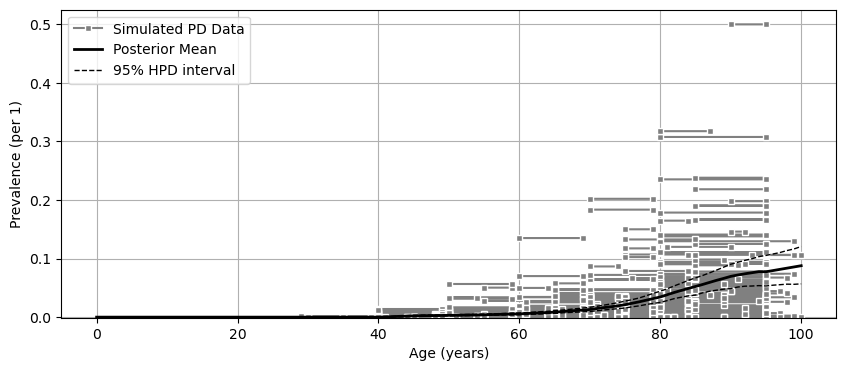

/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/pipeline.py:1410: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hpd = pm.stats.hdi(pred, hdi_prob=0.95)


✅ Figure saved to results/NR/Late-dry/prevalence_2021_Late-dry_Male.png


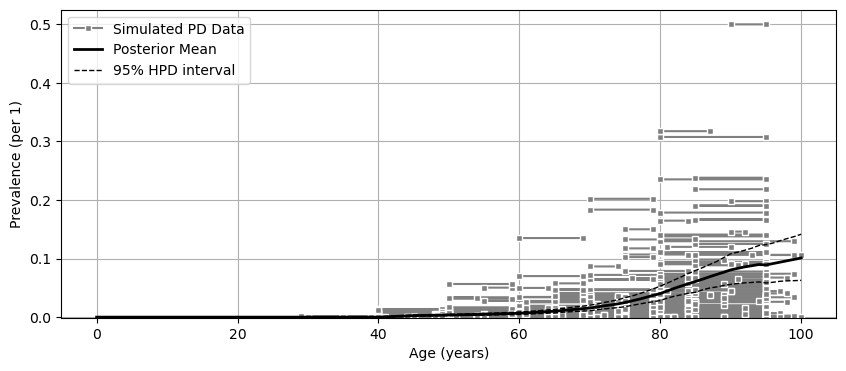

/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/pipeline.py:1410: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hpd = pm.stats.hdi(pred, hdi_prob=0.95)


✅ Figure saved to results/NR/Late-dry/prevalence_2021_Late-dry_Female.png


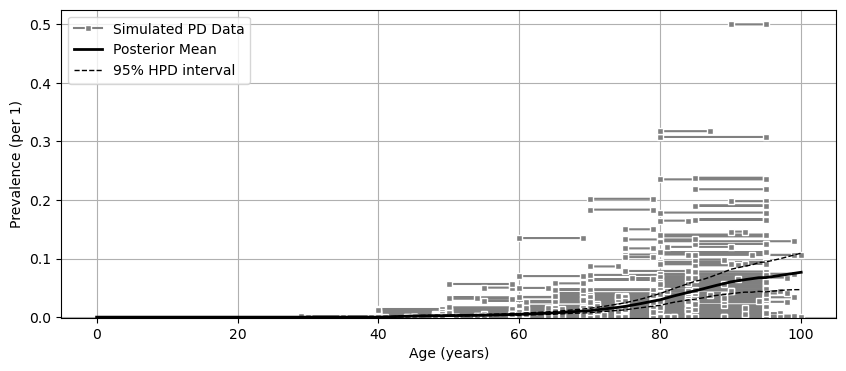

--------------------------------------------------------------------------------
[2025-09-06 20:42:33] [STAGE=Late-wet] Loading idata from: results/NR/Late-wet/idata_Late-wet.pkl
[2025-09-06 20:42:34] [STAGE=Late-wet] idata loaded. (took 0.7s)
[2025-09-06 20:42:34] [STAGE=Late-wet] Rebuilding pm_model skeleton...
#rows(input_data): 491
#unique location_id: 34
#nodes: 233, #edges: 232, global_id: 1 (Global)
Constant beta_p_x_lpa
Constant beta_p_x_sdi
HalfNormal beta_p_x_sev
[2025-09-06 20:43:18] [STAGE=Late-wet] pm_model ready. (took 43.8s)


/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/pipeline.py:1410: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hpd = pm.stats.hdi(pred, hdi_prob=0.95)


✅ Figure saved to results/NR/Late-wet/prevalence_2021_Late-wet_Both.png


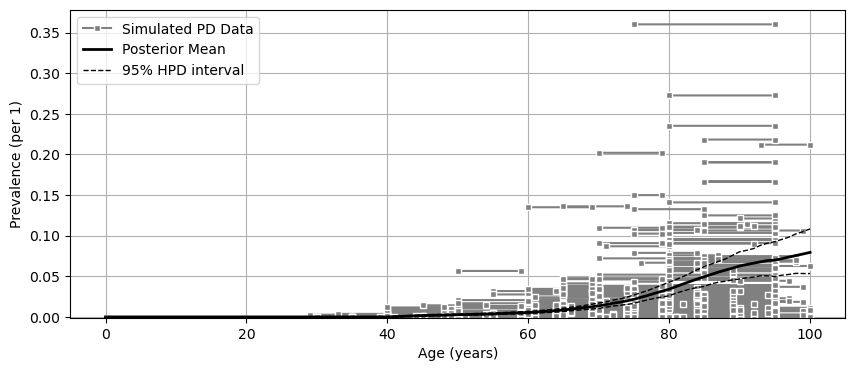

/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/pipeline.py:1410: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hpd = pm.stats.hdi(pred, hdi_prob=0.95)


✅ Figure saved to results/NR/Late-wet/prevalence_2021_Late-wet_Male.png


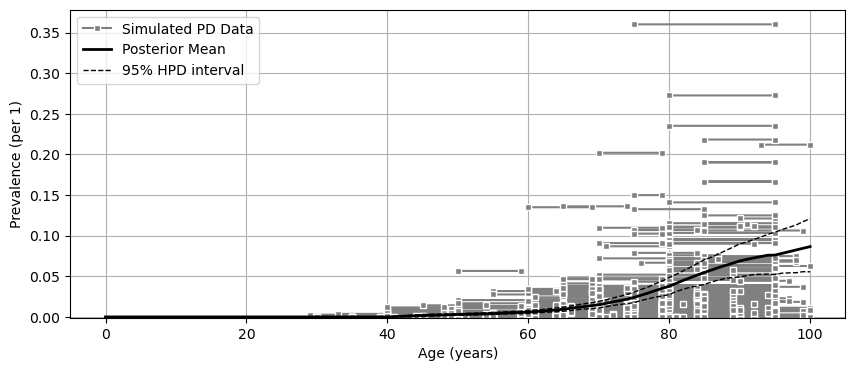

/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/pipeline.py:1410: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hpd = pm.stats.hdi(pred, hdi_prob=0.95)


✅ Figure saved to results/NR/Late-wet/prevalence_2021_Late-wet_Female.png


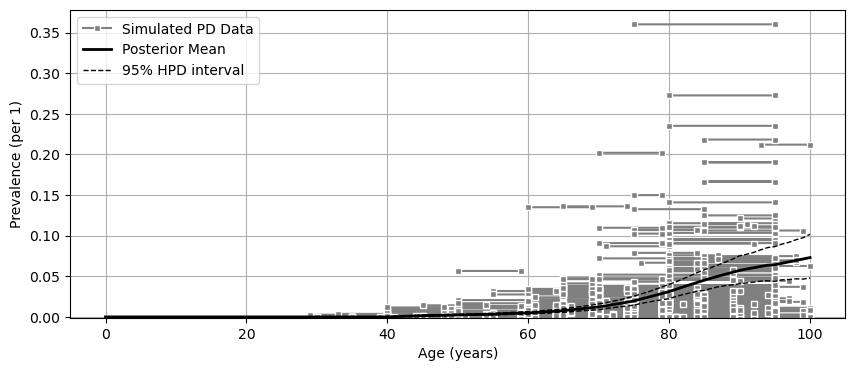

[2025-09-06 20:47:13] [END] All stages exported. (elapsed 7.84 min)


In [21]:
import os, time, datetime, pickle
import numpy as np
import pandas as pd


# dt = 'p'  # 위에서 이미 정의했다고 가정
# csv_files, pipeline, output_template_path, parameters_path, hierarchy_path, detailed_pop_path 도 동일하게 존재한다고 가정

def _now():
    import datetime as _dt
    return _dt.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

global_start = time.time()
print("="*80)
print(f"[{_now()}] [START] Re-loading idata & exporting world CSVs")
print("="*80)

YEARS = list(range(1990, 2022))
sexes = ('Both', 'Male', 'Female')  # world_predict_fast 기본값과 동일

print([csv_files[1],csv_files[3]])

for input_data_path in [csv_files[1],csv_files[3]]:
    stage = os.path.basename(input_data_path) \
                .replace("joined_input_data_NR_", "") \
                .replace(".csv","")
    stage_dir = os.path.join("results/NR", stage)
    idata_path = os.path.join(stage_dir, f"idata_{stage}.pkl")

    print("-"*80)
    print(f"[{_now()}] [STAGE={stage}] Loading idata from: {idata_path}")
    if not os.path.exists(idata_path):
        print(f"[{_now()}] [STAGE={stage}] SKIP: idata pickle not found.")
        continue

    # --- 1) idata 로드 ---
    t0 = time.time()
    with open(idata_path, "rb") as f:
        idata = pickle.load(f)
    print(f"[{_now()}] [STAGE={stage}] idata loaded. (took {time.time()-t0:.1f}s)")

    # --- 2) pm_model 재구성 (샘플링 X, PyMC objects만) ---
    #      world_predict_fast는 coords['age'], shared_data 등을 사용하므로 pipeline 초기화 + generate_pymc_objects만 필요
    print(f"[{_now()}] [STAGE={stage}] Rebuilding pm_model skeleton...")
    t0 = time.time()
    pm_model = pipeline.initialize_pipeline(
        input_data_path      = input_data_path,
        output_template_path = output_template_path,
        parameters_path      = parameters_NR_path,
        hierarchy_path       = hierarchy_path,
        detailed_pop_path    = detailed_pop_path,
        verbose              = True
    )
    pipeline.generate_pymc_objects(pm_model, data_type=dt)
    print(f"[{_now()}] [STAGE={stage}] pm_model ready. (took {time.time()-t0:.1f}s)")

    # 간단한 검증: 필요한 posterior 키 존재 여부
    if 'constrained_mu_age_p' not in idata.posterior:
        raise KeyError(f"[{stage}] idata.posterior['constrained_mu_age_p']가 없습니다.")
    
    sexes = ('Both', 'Male', 'Female')
    for sex in sexes:
        pred = pipeline.predict_for(
            dt                  = dt,
            pm_model            = pm_model,
            idata               = idata, 
            root_area           = 'Global',
            root_sex            = 'Both',
            location_id         = 1,
            sex_name            = sex,
            year_id             = 2021,
            population_weighted = True
        )
        fig_path = os.path.join(stage_dir, f"prevalence_2021_{stage}_{sex}.png")
        pipeline.visualize_pred(pred, pm_model.shared_data[f"input_data_{dt}"], save_path=fig_path)

   

print("="*80)
print(f"[{_now()}] [END] All stages exported. (elapsed {(time.time()-global_start)/60:.2f} min)")
print("="*80)


# World Prediction

In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import pickle

def plot_global_triple_trend_by_sex(
    df: pd.DataFrame,
    save_dir: str = ".",
    sexes = ("Both", "Male", "Female"),
    percent: bool = True,
    cases_unit: float = 1e6
):
    """
    df: world_predict() 결과 DataFrame
    save_dir: 결과 PNG 저장 폴더
    sexes: 그릴 성별 목록 ("Both","Male","Female" 등)
    percent: 유병률을 %로 표시할지
    cases_unit: 절대 환자수 축의 단위 스케일 (1e6=백만)
    """
    os.makedirs(save_dir, exist_ok=True)

    # 공통 컬럼 체크
    required_cols = {
        "level","sex_name", "year",
            "mean_prev","lower_prev_p95","upper_prev_p95",
            "mean_prev_std","lower_prev_std_p95","upper_prev_std_p95",
            "mean_cases","lower_cases_p95","upper_cases_p95"
    }
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns in df: {missing}")

    # Global만 사용
    gdf_all = df[df["level"] == 0].copy()
    if gdf_all.empty:
        raise ValueError("No Global (level==0) rows in df.")

    # 색상 팔레트
    colors = plt.get_cmap("tab10").colors
    c1, c2, c3 = colors[0], colors[1], colors[2]

    for sex in sexes:
        gdf = gdf_all[gdf_all["sex_name"] == sex].copy()
        if gdf.empty:
            print(f"[plot] Skip: no rows for sex={sex}")
            continue

        # 중복 연도 체크(성별별)
        dup = gdf["year"].value_counts()
        dup = dup[dup > 1]
        if not dup.empty:
            raise ValueError(f"Global rows have duplicate years for sex={sex}: {dup.index.tolist()}")

        # 정렬 및 선택
        cols = [
            "year",
            "mean_prev","lower_prev_p95","upper_prev_p95",
            "mean_prev_std","lower_prev_std_p95","upper_prev_std_p95",
            "mean_cases","lower_cases_p95","upper_cases_p95"
        ]
        agg = gdf.sort_values("year")[cols].reset_index(drop=True)

        # 스케일링
        scale = 100.0 if percent else 1.0
        years = agg["year"].to_numpy()

        y_prev      = agg["mean_prev"].to_numpy() * scale
        y_prev_lo   = agg["lower_prev_p95"].to_numpy() * scale
        y_prev_hi   = agg["upper_prev_p95"].to_numpy() * scale

        y_prev_std    = agg["mean_prev_std"].to_numpy() * scale
        y_prev_std_lo = agg["lower_prev_std_p95"].to_numpy() * scale
        y_prev_std_hi = agg["upper_prev_std_p95"].to_numpy() * scale

        y_cases    = agg["mean_cases"].to_numpy() / cases_unit
        y_cases_lo = agg["lower_cases_p95"].to_numpy() / cases_unit
        y_cases_hi = agg["upper_cases_p95"].to_numpy() / cases_unit

        # 그림
        fig, ax = plt.subplots(figsize=(8.5, 5))

        # 유병률
        line1, = ax.plot(years, y_prev, linewidth=2, color=c1, label="Prevalence")
        ax.fill_between(years, y_prev_lo, y_prev_hi, alpha=0.20, linewidth=0, color=c1)

        # 표준화 유병률
        line2, = ax.plot(years, y_prev_std, linewidth=2, linestyle="--", color=c2, label="Standardized prevalence")
        ax.fill_between(years, y_prev_std_lo, y_prev_std_hi, alpha=0.15, linewidth=0, color=c2)

        ax.set_xlabel("Year")
        ax.set_ylabel(f"Prevalence ({'%' if percent else 'per 1'})")
        ax.grid(True, alpha=0.3)

        # 절대 환자수 (오른쪽 축)
        ax2 = ax.twinx()
        line3, = ax2.plot(years, y_cases, linewidth=2, color=c3, label=f"Cases (/{int(cases_unit):,})")
        ax2.fill_between(years, y_cases_lo, y_cases_hi, alpha=0.15, linewidth=0, color=c3)
        ax2.set_ylabel(f"Cases (× {int(cases_unit):,})")

        # 범례
        lines = [line1, line2, line3]
        labels = [ln.get_label() for ln in lines]
        ax.legend(lines, labels, loc="upper left")

        plt.title(f"Global AMD over time — {sex}")
        plt.tight_layout()

        # 저장
        sex_safe = sex.replace(" ", "_")
        out_png = os.path.join(save_dir, f"global_triple_trend_{sex_safe}.png")
        plt.savefig(out_png, dpi=200)
        plt.close(fig)
        print(f"[plot] Saved {out_png}")


In [14]:
import os, time, datetime, pickle
import numpy as np
import pandas as pd


# dt = 'p'  # 위에서 이미 정의했다고 가정
# csv_files, pipeline, output_template_path, parameters_path, hierarchy_path, detailed_pop_path 도 동일하게 존재한다고 가정

def _now():
    import datetime as _dt
    return _dt.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

global_start = time.time()
print("="*80)
print(f"[{_now()}] [START] Re-loading idata & exporting world CSVs")
print("="*80)

YEARS = list(range(1990, 2022))
sexes = ('Both', 'Male', 'Female')  # world_predict_fast 기본값과 동일


for input_data_path in [csv_files[1],csv_files[3]]:
    stage = os.path.basename(input_data_path) \
                .replace("joined_input_data_NR_", "") \
                .replace(".csv","")
    stage_dir = os.path.join("results/NR", stage)
    idata_path = os.path.join(stage_dir, f"idata_{stage}.pkl")

    print("-"*80)
    print(f"[{_now()}] [STAGE={stage}] Loading idata from: {idata_path}")
    if not os.path.exists(idata_path):
        print(f"[{_now()}] [STAGE={stage}] SKIP: idata pickle not found.")
        continue

    # --- 1) idata 로드 ---
    t0 = time.time()
    with open(idata_path, "rb") as f:
        idata = pickle.load(f)
    print(f"[{_now()}] [STAGE={stage}] idata loaded. (took {time.time()-t0:.1f}s)")

    # --- 2) pm_model 재구성 (샘플링 X, PyMC objects만) ---
    #      world_predict_fast는 coords['age'], shared_data 등을 사용하므로 pipeline 초기화 + generate_pymc_objects만 필요
    print(f"[{_now()}] [STAGE={stage}] Rebuilding pm_model skeleton...")
    t0 = time.time()
    pm_model = pipeline.initialize_pipeline(
        input_data_path      = input_data_path,
        output_template_path = output_template_path,
        parameters_path      = parameters_NR_path,
        hierarchy_path       = hierarchy_path,
        detailed_pop_path    = detailed_pop_path,
        verbose              = True
    )
    pipeline.generate_pymc_objects(pm_model, data_type=dt)
    print(f"[{_now()}] [STAGE={stage}] pm_model ready. (took {time.time()-t0:.1f}s)")

    # 간단한 검증: 필요한 posterior 키 존재 여부
    if 'constrained_mu_age_p' not in idata.posterior:
        raise KeyError(f"[{stage}] idata.posterior['constrained_mu_age_p']가 없습니다.")

    # --- 3) world_predict 실행 ---
    world_csv = os.path.join(stage_dir, f'1990_2021_{stage}_all_regions.csv')
    print(f"[{_now()}] [STAGE={stage}] Running world_predict → {world_csv}")
    t0 = time.time()
    results = pipeline.world_predict(
        dt               = dt,
        pm_model         = pm_model,
        idata            = idata,
        years            = YEARS,
        output_csv_path  = world_csv,
        target_levels    = {0, 2, 3},
        sexes            = sexes,
        verbose          = True,
    )
    print(f"[{_now()}] [STAGE={stage}] world CSV done. (took {time.time()-t0:.1f}s)")

    # # --- 4) 글로벌 트렌드 플롯(선택): 함수가 있으면 실행 ---
    # fig_global = os.path.join(stage_dir, f"global_prev_trend_{stage}.png")
    # print(f"[{_now()}] [STAGE={stage}] Plotting global trend → {fig_global}")
    # plot_global_triple_trend_by_sex(results, save_dir=stage_dir)

print("="*80)
print(f"[{_now()}] [END] All stages exported. (elapsed {(time.time()-global_start)/60:.2f} min)")
print("="*80)


[2025-09-06 20:23:19] [START] Re-loading idata & exporting world CSVs
--------------------------------------------------------------------------------
[2025-09-06 20:23:19] [STAGE=Late-dry] Loading idata from: results/NR/Late-dry/idata_Late-dry.pkl
[2025-09-06 20:23:20] [STAGE=Late-dry] idata loaded. (took 0.9s)
[2025-09-06 20:23:20] [STAGE=Late-dry] Rebuilding pm_model skeleton...
#rows(input_data): 447
#unique location_id: 33
#nodes: 233, #edges: 232, global_id: 1 (Global)
Constant beta_p_x_lpa
Constant beta_p_x_sdi
HalfNormal beta_p_x_sev
[2025-09-06 20:23:22] [STAGE=Late-dry] pm_model ready. (took 2.5s)
[2025-09-06 20:23:22] [STAGE=Late-dry] Running world_predict → results/NR/Late-dry/1990_2021_Late-dry_all_regions.csv
[world_predict] Processing year=1990, sex=Both
    leaf=33 → node=1 (Global), year=1990, sex=Both :: 0.0% done
    leaf=33 → node=32 (Central Asia), year=1990, sex=Both :: 0.0% done
    leaf=33 → node=33 (Armenia), year=1990, sex=Both :: 0.0% done
    leaf=34 → node=

KeyboardInterrupt: 

In [19]:
df = pd.read_csv('./results/NR/Late-dry/1990_2021_Late-dry_all_regions.csv')
plot_global_triple_trend_by_sex(df=df,save_dir='./results/NR/Late-dry')

df = pd.read_csv('./results/NR/Late-wet/1990_2021_Late-wet_all_regions.csv')
plot_global_triple_trend_by_sex(df=df,save_dir='./results/NR/Late-wet')

[plot] Saved ./results/NR/Late-dry/global_triple_trend_Both.png
[plot] Saved ./results/NR/Late-dry/global_triple_trend_Male.png
[plot] Saved ./results/NR/Late-dry/global_triple_trend_Female.png
[plot] Saved ./results/NR/Late-wet/global_triple_trend_Both.png
[plot] Saved ./results/NR/Late-wet/global_triple_trend_Male.png
[plot] Saved ./results/NR/Late-wet/global_triple_trend_Female.png


# ETH

In [7]:
parameters_ETH_path = f'{basedir}/parameters_ETH_not_Late.jsonc'
parameters_ETH_Late_path = f'{basedir}/parameters_ETH_Late.jsonc'

dir_path = './data_ready/input_data/ETH/'
csv_files = list_all_csv_files(dir_path)
csv_files

['./data_ready/input_data/ETH/African/joined_input_data_African_ancestry_Late-dry.csv',
 './data_ready/input_data/ETH/African/joined_input_data_African_ancestry_Early to intermediate.csv',
 './data_ready/input_data/ETH/African/joined_input_data_African_ancestry_Intermediate.csv',
 './data_ready/input_data/ETH/African/joined_input_data_African_ancestry_Late-wet.csv',
 './data_ready/input_data/ETH/European/joined_input_data_European_ancestry_Late-dry.csv',
 './data_ready/input_data/ETH/European/joined_input_data_European_ancestry_Early.csv',
 './data_ready/input_data/ETH/European/joined_input_data_European_ancestry_Intermediate.csv',
 './data_ready/input_data/ETH/European/joined_input_data_European_ancestry_Late-wet.csv',
 './data_ready/input_data/ETH/Hispanic/joined_input_data_Hispanic_Intermediate.csv',
 './data_ready/input_data/ETH/Hispanic/joined_input_data_Hispanic_Early.csv',
 './data_ready/input_data/ETH/Hispanic/joined_input_data_Hispanic_Late-wet.csv',
 './data_ready/input_data/

[RUN] Group=African_ancestry | Stage=Late-dry (./data_ready/input_data/ETH/African/joined_input_data_African_ancestry_Late-dry.csv)
[PARAMS] Using: /Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/data_ready/params/parameters_ETH_Late.jsonc


Multiprocess sampling (8 chains in 4 jobs)
CompoundStep
>Metropolis: [gamma_p]
>Metropolis: [eta_p]
Sampling 8 chains for 1_000 tune and 4_000 draw iterations (8_000 + 32_000 draws total) took 12 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/pipeline.py:1410: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hpd = pm.stats.hdi(pred, hdi_prob=0.95)


✅ Figure saved to results/ETH/African_ancestry/Late-dry/age_curve_2021_African_ancestry_Late-dry.png


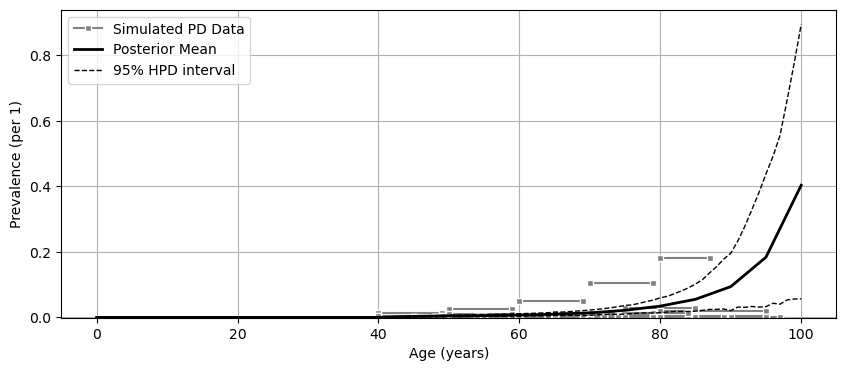

[SAVE] results/ETH/African_ancestry/Late-dry/age_curve_2021_African_ancestry_Late-dry.csv
[RUN] Group=African_ancestry | Stage=Early to intermediate (./data_ready/input_data/ETH/African/joined_input_data_African_ancestry_Early to intermediate.csv)
[PARAMS] Using: /Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/data_ready/params/parameters_ETH_not_Late.jsonc


Multiprocess sampling (8 chains in 4 jobs)
CompoundStep
>Metropolis: [gamma_p]
>Metropolis: [eta_p]
Sampling 8 chains for 1_000 tune and 4_000 draw iterations (8_000 + 32_000 draws total) took 13 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/pipeline.py:1410: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hpd = pm.stats.hdi(pred, hdi_prob=0.95)


✅ Figure saved to results/ETH/African_ancestry/Early-to-intermediate/age_curve_2021_African_ancestry_Early-to-intermediate.png


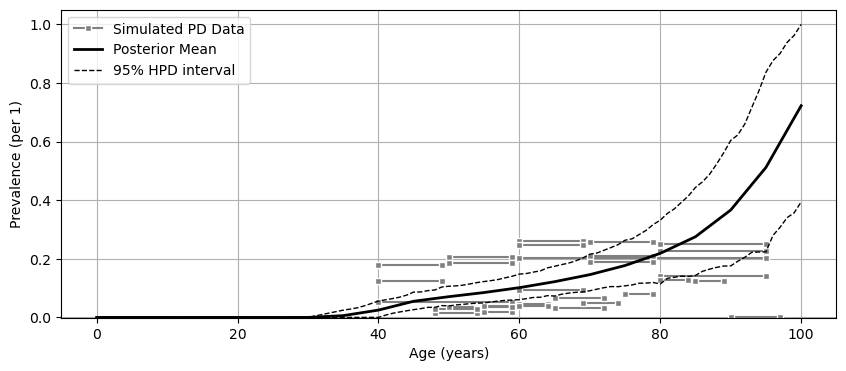

[SAVE] results/ETH/African_ancestry/Early-to-intermediate/age_curve_2021_African_ancestry_Early-to-intermediate.csv
[RUN] Group=African_ancestry | Stage=Intermediate (./data_ready/input_data/ETH/African/joined_input_data_African_ancestry_Intermediate.csv)
[PARAMS] Using: /Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/data_ready/params/parameters_ETH_not_Late.jsonc


Multiprocess sampling (8 chains in 4 jobs)
CompoundStep
>Metropolis: [gamma_p]
>Metropolis: [eta_p]
Sampling 8 chains for 1_000 tune and 4_000 draw iterations (8_000 + 32_000 draws total) took 12 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/pipeline.py:1410: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hpd = pm.stats.hdi(pred, hdi_prob=0.95)


✅ Figure saved to results/ETH/African_ancestry/Intermediate/age_curve_2021_African_ancestry_Intermediate.png


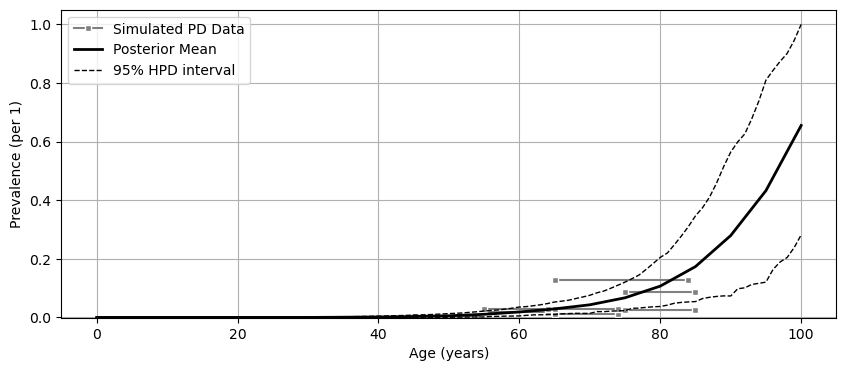

[SAVE] results/ETH/African_ancestry/Intermediate/age_curve_2021_African_ancestry_Intermediate.csv
[RUN] Group=African_ancestry | Stage=Late-wet (./data_ready/input_data/ETH/African/joined_input_data_African_ancestry_Late-wet.csv)
[PARAMS] Using: /Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/data_ready/params/parameters_ETH_Late.jsonc


Multiprocess sampling (8 chains in 4 jobs)
CompoundStep
>Metropolis: [gamma_p]
>Metropolis: [eta_p]
Sampling 8 chains for 1_000 tune and 4_000 draw iterations (8_000 + 32_000 draws total) took 14 seconds.
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/pipeline.py:1410: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hpd = pm.stats.hdi(pred, hdi_prob=0.95)


✅ Figure saved to results/ETH/African_ancestry/Late-wet/age_curve_2021_African_ancestry_Late-wet.png


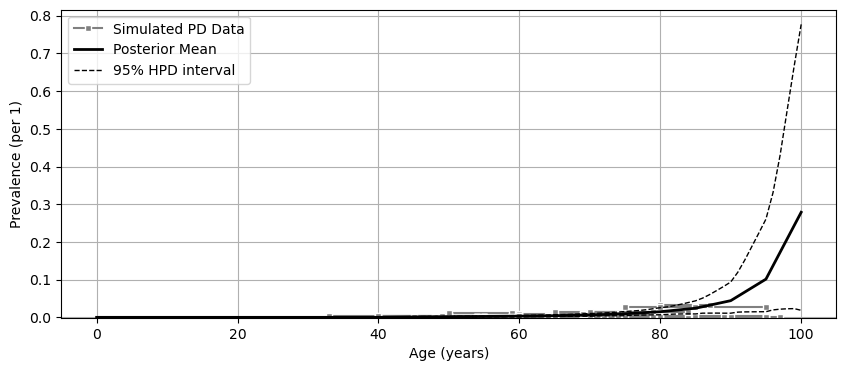

[SAVE] results/ETH/African_ancestry/Late-wet/age_curve_2021_African_ancestry_Late-wet.csv
[RUN] Group=European_ancestry | Stage=Late-dry (./data_ready/input_data/ETH/European/joined_input_data_European_ancestry_Late-dry.csv)
[PARAMS] Using: /Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/data_ready/params/parameters_ETH_Late.jsonc


Multiprocess sampling (8 chains in 4 jobs)
CompoundStep
>Metropolis: [gamma_p]
>Metropolis: [eta_p]
Sampling 8 chains for 1_000 tune and 4_000 draw iterations (8_000 + 32_000 draws total) took 13 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/pipeline.py:1410: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hpd = pm.stats.hdi(pred, hdi_prob=0.95)


✅ Figure saved to results/ETH/European_ancestry/Late-dry/age_curve_2021_European_ancestry_Late-dry.png


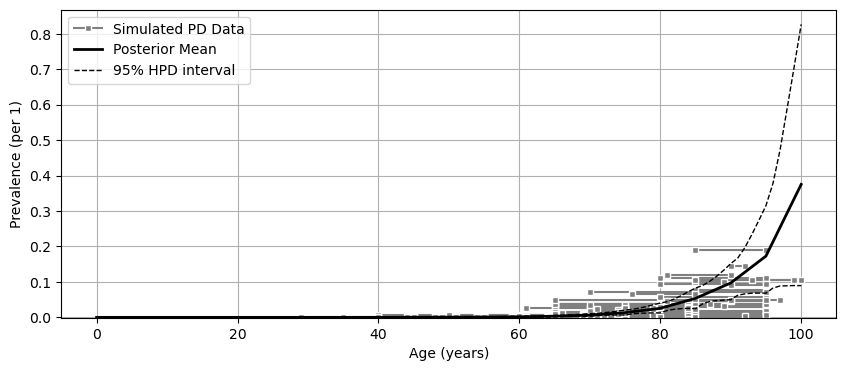

[SAVE] results/ETH/European_ancestry/Late-dry/age_curve_2021_European_ancestry_Late-dry.csv
[RUN] Group=European_ancestry | Stage=Early (./data_ready/input_data/ETH/European/joined_input_data_European_ancestry_Early.csv)
[PARAMS] Using: /Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/data_ready/params/parameters_ETH_not_Late.jsonc


Multiprocess sampling (8 chains in 4 jobs)
CompoundStep
>Metropolis: [gamma_p]
>Metropolis: [eta_p]
Sampling 8 chains for 1_000 tune and 4_000 draw iterations (8_000 + 32_000 draws total) took 13 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/pipeline.py:1410: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hpd = pm.stats.hdi(pred, hdi_prob=0.95)


✅ Figure saved to results/ETH/European_ancestry/Early/age_curve_2021_European_ancestry_Early.png


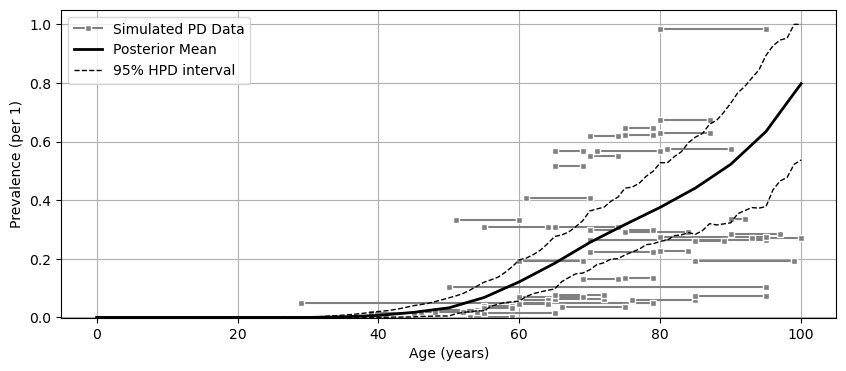

[SAVE] results/ETH/European_ancestry/Early/age_curve_2021_European_ancestry_Early.csv
[RUN] Group=European_ancestry | Stage=Intermediate (./data_ready/input_data/ETH/European/joined_input_data_European_ancestry_Intermediate.csv)
[PARAMS] Using: /Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/data_ready/params/parameters_ETH_not_Late.jsonc


In [ ]:
import os, re, numpy as np, pandas as pd

def slugify(s: str) -> str:
    s = s.strip()
    s = s.replace(" to ", "-to-")
    s = re.sub(r"\s+", "-", s)
    s = re.sub(r"[^A-Za-z0-9._-]+", "", s)
    return s

def parse_group_stage(path: str):
    base = os.path.basename(path)
    name = base[:-4] if base.lower().endswith(".csv") else base
    if not name.startswith("joined_input_data_"):
        raise ValueError(f"Unexpected filename: {base}")
    tail = name[len("joined_input_data_"):]
    split_idx = tail.rfind('_')
    if split_idx == -1:
        raise ValueError(f"Cannot parse group/stage from: {base}")
    group = tail[:split_idx]
    stage = tail[split_idx+1:]
    return group, stage

YEAR_FOR_AGE_CURVE = 2021

for input_data_path in csv_files:
    group, stage = parse_group_stage(input_data_path)
    group_slug = slugify(group)
    stage_slug = slugify(stage)

    print(f"[RUN] Group={group} | Stage={stage} ({input_data_path})")

    # 결과 폴더 (변경 없음)
    out_dir = os.path.join("results", "ETH", group_slug, stage_slug)
    os.makedirs(out_dir, exist_ok=True)

    # ----- 스테이지별 파라미터 파일 선택 -----
    stage_key = stage.lower().replace(" ", "-")   # e.g., 'Late-wet' -> 'late-wet'
    if stage_key in {"late-wet", "late-dry"}:
        params_path = parameters_ETH_Late_path
    else:
        params_path = parameters_ETH_path
    print(f"[PARAMS] Using: {params_path}")

    # ----- 파이프라인 -----
    pm_model = pipeline.initialize_pipeline(
        input_data_path=input_data_path,
        output_template_path=output_template_path,
        parameters_path=params_path,      # ← 여기만 조건 적용
        hierarchy_path=hierarchy_path,
        detailed_pop_path=detailed_pop_path,
        verbose=False
    )

    pipeline.generate_pymc_objects(pm_model=pm_model, data_type=dt)
    map_estimate = pipeline.return_map_estimate(pm_model=pm_model, verbose=False)
    idata = pipeline.return_idata(pm_model     = pm_model, 
                                  map_estimate   = map_estimate, 
                                  draws          = 4000,
                                  tune           = 1000,
                                  chains         = 8,
                                  cores          = 4,
                                  target_accept  = 0.9,
                                  use_advi       = False,
                                  verbose=False,
                                  use_metropolis=True)

    pred = pipeline.predict_for(
        dt                  = dt,
        pm_model            = pm_model,
        idata               = idata, 
        root_area           = 'Global',
        root_sex            = 'Both',
        root_year           = 'all',
        location_id         = 1,
        sex_name            = 'Both',
        year_id             = YEAR_FOR_AGE_CURVE,
        population_weighted = True
    )

    # === 출력 파일명/경로: 변경 없음 ===
    fig_path = os.path.join(out_dir, f"age_curve_{YEAR_FOR_AGE_CURVE}_{group_slug}_{stage_slug}.png")
    pipeline.visualize_pred(pred, pm_model.shared_data[f"input_data_{dt}"], save_path=fig_path)

    mean_vals  = pred.mean(axis=0)
    lower_vals = np.percentile(pred,  2.5, axis=0)
    upper_vals = np.percentile(pred, 97.5, axis=0)

    ages = np.arange(pred.shape[1])  # 0..100 가정
    df_age = pd.DataFrame({
        'mean'     : mean_vals,
        'lower_ci' : lower_vals,
        'upper_ci' : upper_vals
    }, index=ages).rename_axis('age')

    age_csv = os.path.join(out_dir, f"age_curve_{YEAR_FOR_AGE_CURVE}_{group_slug}_{stage_slug}.csv")
    df_age.to_csv(age_csv)
    print(f"[SAVE] {age_csv}")

print("[DONE] All ETH runs finished.")
